In [1]:
### Import základních knihoven a modulů pro zpracování a analýzu dat

import os  # Práce se souborovým systémem (pro manipulaci se soubory a složkami)
import pandas as pd  # Manipulace a analýza tabulkových dat
import numpy as np  # Matematické operace a práce s n-rozměrnými poli

# Import knihoven pro vizualizaci dat
import matplotlib.pyplot as plt  # Vykreslování grafů
from matplotlib.legend_handler import HandlerLine2D  # Přizpůsobení legend
from matplotlib.backends.backend_pdf import PdfPages  # Ukládání grafů do PDF

# Import knihovny pro odstranění pozadí ze spektrálních dat
from pybaselines import Baseline, utils  # Nástroje pro baseline korekci

# Import knihoven pro fitování dat
import lmfit as lm  # Fitování modelů a optimalizace
from lmfit import Model, Parameters, Parameter, report_fit, minimize, Minimizer

# Import nástroje pro detekci vrcholů (peaks) ve spektrálních datech
from scipy.signal import find_peaks

# Import vlastního modulu s funkcemi pro práci s píky
from assign_peaks import *  # Vlastní algoritmus definovaný v souboru assign_peaks.py



In [2]:
### Průměrování souborů s experimentálními daty
# Funkce pro zpracování datových souborů v zadané složce
def process_files(txt_folder, num_files):
    # Nastavení výstupního adresáře (vytvoření, pokud neexistuje)
    output_dir = os.path.join(os.getcwd(), 'aver_dir')  # Nastavíme podadresář 'wdir'
    os.makedirs(output_dir, exist_ok=True)  # Vytvoříme složku, pokud ještě neexistuje

    # Načteme seznam souborů ve složce (ignorujeme skryté soubory)
    files = [f for f in os.listdir(txt_folder) if not f.startswith('.')]
    files = files[:num_files]  # Omezíme počet souborů na zpracování podle zadaného limitu

    # Inicializujeme seznamy pro uložení načtených dat
    df_tim, df_amp = [], []

    # Procházíme každý soubor v seznamu a načítáme sloupce dat
    for f in files:
        print(f)  # Vypsání názvu aktuálního souboru
        txt_file = os.path.join(txt_folder, f)
        
        # Načteme časová data (sloupec 0) a amplitudy (sloupec 1) ze souboru
        df_tim.append(pd.read_csv(txt_file, header=5, sep=",", usecols=[0]))
        df_amp.append(pd.read_csv(txt_file, header=5, sep=",", usecols=[1]))

    # Sloučíme všechna časová a amplitudová data do jediného DataFrame
    df_all_tim = pd.concat(df_tim, ignore_index=True, axis=1)
    df_all_amp = pd.concat(df_amp, ignore_index=True, axis=1)

    # Uložíme sloučená data do výstupního adresáře
    df_all_tim.to_csv(os.path.join(output_dir, 'time.csv'), sep=',')
    df_all_amp.to_csv(os.path.join(output_dir, 'ampl.csv'), sep=',')

    # Vypočítáme průměry pro časová data a amplitudy
    df_mean_tim = df_all_tim.mean(axis=1)
    df_mean_tim.to_csv(os.path.join(output_dir, 'time_aver.txt'), sep=',')  # Uložíme průměry času
    df_mean_amp = df_all_amp.mean(axis=1)
    df_mean_amp.to_csv(os.path.join(output_dir, 'ampl_aver.txt'), sep=',')  # Uložíme průměry amplitud

    # Spojíme průměrná data a uložíme je do jednoho souboru
    with open(os.path.join(output_dir, 'averaged.txt'), 'w') as f:
        pd.concat([df_mean_tim, df_mean_amp], axis=1).to_csv(f, sep=',', index=False, header=False)
    
    
    # Informace o dokončení procesu
    print(f'!Averaging finished! Výstupy jsou uloženy v adresáři: {output_dir}')

# Příklad použití funkce
txt_folder = '2fexp5'  # Název složky obsahující soubory
num_files = 300

process_files(txt_folder, num_files)

C2_2025-03-11_PS_K2_5proCO2_00000.txt
C2_2025-03-11_PS_K2_5proCO2_00001.txt
C2_2025-03-11_PS_K2_5proCO2_00002.txt
C2_2025-03-11_PS_K2_5proCO2_00003.txt
C2_2025-03-11_PS_K2_5proCO2_00004.txt
C2_2025-03-11_PS_K2_5proCO2_00005.txt
C2_2025-03-11_PS_K2_5proCO2_00006.txt
C2_2025-03-11_PS_K2_5proCO2_00007.txt
C2_2025-03-11_PS_K2_5proCO2_00008.txt
C2_2025-03-11_PS_K2_5proCO2_00009.txt
C2_2025-03-11_PS_K2_5proCO2_00010.txt
C2_2025-03-11_PS_K2_5proCO2_00011.txt
C2_2025-03-11_PS_K2_5proCO2_00012.txt
C2_2025-03-11_PS_K2_5proCO2_00013.txt
C2_2025-03-11_PS_K2_5proCO2_00014.txt
C2_2025-03-11_PS_K2_5proCO2_00015.txt
C2_2025-03-11_PS_K2_5proCO2_00016.txt
C2_2025-03-11_PS_K2_5proCO2_00017.txt
C2_2025-03-11_PS_K2_5proCO2_00018.txt
C2_2025-03-11_PS_K2_5proCO2_00019.txt
C2_2025-03-11_PS_K2_5proCO2_00020.txt
C2_2025-03-11_PS_K2_5proCO2_00021.txt
C2_2025-03-11_PS_K2_5proCO2_00022.txt
C2_2025-03-11_PS_K2_5proCO2_00023.txt
C2_2025-03-11_PS_K2_5proCO2_00024.txt
C2_2025-03-11_PS_K2_5proCO2_00025.txt
C2_2025-03-1

!Vzorkovací rychlost datových sad je 5000 vzorků/s!
Graf byl úspěšně uložen jako první stránka do 'out2f_exp.pdf'.


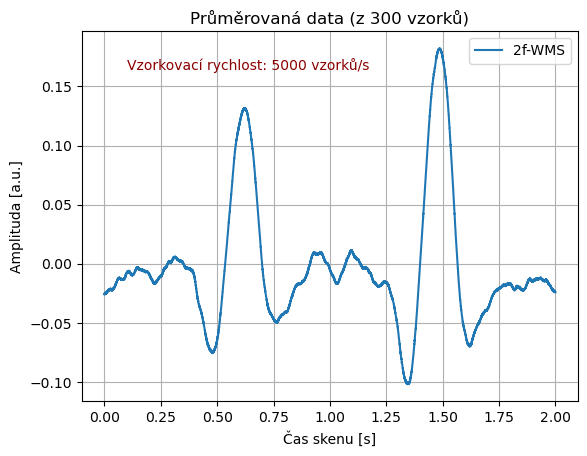

In [3]:
### Načtení a vykreslení průměrovaných dat (z pracovního adresáře)

# Nastavení cesty k pracovnímu adresáři
aver_dir = os.path.join(os.getcwd(), 'aver_dir')  # Pracovní adresář pro vstupy
time_file = os.path.join(aver_dir, 'time_aver.txt')  # Soubor s časovými daty
ampl_file = os.path.join(aver_dir, 'ampl_aver.txt')  # Soubor s amplitudovými daty

# Načtení průměrovaných dat ze souborů
df_mean_tim = pd.read_csv(time_file, sep=',', header=None, skiprows=1)  # Časová data
df_mean_amp = pd.read_csv(ampl_file, sep=',', header=None, skiprows=1)  # Amplitudy

# Převod dat na NumPy pole pro další zpracování
xs = df_mean_tim[1].to_numpy()  # Časová data (sloupec 1)
ys = df_mean_amp[1].to_numpy()  # Amplitudy (sloupec 1)

# Posun hodnot na x-ové ose o 2 sekundy
xs = xs

# Výpočet vzorkovací rychlosti
number_of_samples = len(xs)  # Počet vzorků
max_time = np.max(xs)  # Maximální čas
SpS = int(number_of_samples / max_time)  # Počet vzorků za sekundu
print(f"!Vzorkovací rychlost datových sad je {SpS} vzorků/s!")  # Výstup vzorkovací rychlosti

# Vytvoření PDF souboru
Out1 = PdfPages('out2f_exp.pdf')

# Vykreslení grafu
plt.figure()  # Vytvoření nové figure pro graf
plt.plot(xs, ys, label="2f-WMS")  # Vykreslení dat
plt.xlabel('Čas skenu [s]')  # Popisek osy X
plt.ylabel('Amplituda [a.u.]')  # Popisek osy Y
plt.title(f"Průměrovaná data (z {num_files} vzorků)")  # Dynamický název grafu
plt.legend(loc="upper right")  # Zobrazení legendy
plt.grid(True)  # Přidání mřížky

# Přidání textu o vzorkovací rychlosti
plt.text(0.05 * max_time, 0.9 * np.max(ys), f"Vzorkovací rychlost: {SpS} vzorků/s", fontsize=10, color='darkred')

# Uložení grafu do PDF souboru
Out1.savefig()  # Uložení aktuálního grafu do PDF
#plt.close()  # Zavření okna grafu (ponecháno pro ladění)

# Uzavření PDF souboru
#Out1.close()
print("Graf byl úspěšně uložen jako první stránka do 'out2f_exp.pdf'.")

Graf byl úspěšně uložen jako druhá stránka do 'out2f_exp.pdf'.


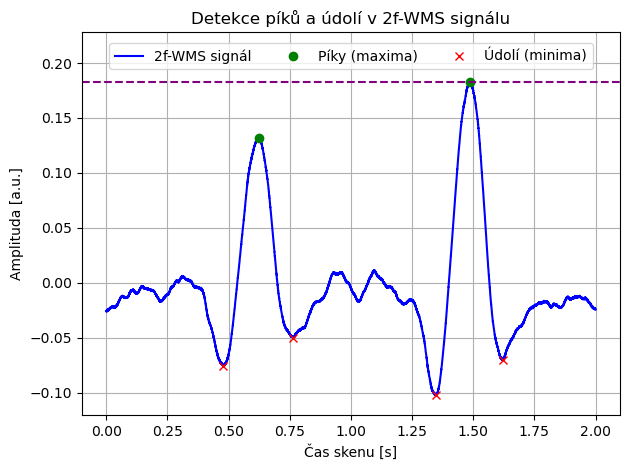

In [4]:
### Hledání pozic maxim (píků) a minim (údolí)

# Dynamické určení hodnoty height
max_signal = np.max(ys)  # Maximální hodnota signálu
peak_height = max_signal / 2  # Polovina maximální hodnoty pro píky
valley_height = max_signal / 4  # Čtvrtina maximální hodnoty pro údolí

# Hledání pozic maxim (píků) a minim (údolí)
peaks, _ = find_peaks(ys, height=peak_height, distance=500, width=250)
valleys, _ = find_peaks(-ys, height=valley_height, distance=450, width=250)

#if len(valleys) >= 4:
#    valleys = np.delete(valleys, 5)  # Odstraní třetí prvek (index 2)
#if len(valleys) >= 3:
#    valleys = np.delete(valleys, 2)  # Odstraní třetí prvek (index 2)

# Vykreslení signálu s vyznačenými píkami a údolími
plt.figure()

# Zvýšení maximální hodnoty osy y pro prostor na legendu
y_margin = 0.25 * max_signal  # Přidání 20 % k maximální hodnotě signálu
plt.ylim(-0.66 * max_signal, max_signal + y_margin)  # Nastavení rozsahu osy y

plt.plot(xs, ys, label="2f-WMS signál", color="blue")  # Původní signál
plt.plot(xs[peaks], ys[peaks], "o", label="Píky (maxima)", color="green")  # Označení píků
plt.plot(xs[valleys], ys[valleys], "x", label="Údolí (minima)", color="red")  # Označení údolí

# Přidání horizontální čárkované čáry pro maximální hodnotu signálu
plt.axhline(y=max_signal, color='purple', linestyle='dashed')

# Přizpůsobení legendy do tří sloupců
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 0.99), ncol=3, fontsize=10)

# Přizpůsobení grafu
plt.xlabel("Čas skenu [s]")  # Popisek osy x
plt.ylabel("Amplituda [a.u.]")  # Popisek osy y
plt.title("Detekce píků a údolí v 2f-WMS signálu")  # Název grafu
plt.grid(True)  # Přidání mřížky
plt.tight_layout()  # Automatické přizpůsobení prvků grafu

# Uložení grafu do PDF souboru
Out1.savefig()  # Uložení aktuálního grafu do PDF
#plt.close()  # Zavření okna grafu (ponecháno pro ladění)

# Uzavření PDF souboru
Out1.close()
print("Graf byl úspěšně uložen jako druhá stránka do 'out2f_exp.pdf'.")

In [5]:
# Definice třídy pro reprezentaci jednoho píku
class Peak2f:
    def __init__(self, max_val_x, min_left_x, min_right_x, s2_max, s2_ampl):
        self.max_x = max_val_x  # Pozice maxima píku
        self.min_lx = min_left_x  # Pozice levého minima
        self.min_rx = min_right_x  # Pozice pravého minima
        self.s2_max = s2_max  # Maximální hodnota amplitudy
        self.s2_ampl = s2_ampl  # Amplituda píku

# Funkce pro ověření konzistence délky maxima a minima
def VerifyPeaksLength(max_xs, min_xs, peak_objects):
    if 2 * len(max_xs) == len(min_xs) or len(max_xs) == 2 * len(min_xs):
        print('Peaks matched/consistent definition!')
        print('Total number of peaks identified in 2f-WMS signal is: ' + str(len(peak_objects)))
    else:
        print('Peak mismatch/inconsistent definition!')
        print('Positions of detected local maxima in 2f-WMS signal are: ' + str(max_xs))
        print('Positions of detected local minima in 2f-WMS signal are: ' + str(min_xs))
        exit(1)

# Funkce ověřuje, zda je střední hodnota platným píkem mezi dvěma hodnotami
def IsValidPeak(x1, x2, x3):
    return x1 < x2 and x2 < x3

# Funkce pro přiřazení píků (maxima a jejich odpovídající minima)
def AssignPeaks(set1_x, set2_x, set1_y, set2_y):
    peaks = []
    if len(set1_x) < len(set2_x):
        for i in range(len(set1_x)):
            x_left = set2_x[i * 2]
            x_right = set2_x[i * 2 + 1]

            if IsValidPeak(x_left, set1_x[i], x_right):
                ampl = np.abs((set2_y[i * 2] + set2_y[i * 2 + 1]) / 2 - set1_y[i])
                p = Peak2f(set1_x[i], x_left, x_right, np.abs(set1_y[i]), ampl)
                peaks.append(p)
    elif len(set2_x) < len(set1_x):
        for i in range(len(set2_x)):
            x_left = set1_x[i * 2]
            x_right = set1_x[i * 2 + 1]

            if IsValidPeak(x_left, set2_x[i], x_right):
                ampl = np.abs((set1_y[i * 2] + set1_y[i * 2 + 1]) / 2 - set2_y[i])
                p = Peak2f(set2_x[i], x_left, x_right, abs(set2_y[i]), ampl)
                peaks.append(p)

    return peaks

# Funkce pro uložení spektra jednotlivých píků do pracovního adresáře
def SavePeakSpectra(peaks, x, y, in_file, n=2):
    # Nastavení pracovní složky pro výsledky
    output_dir = os.path.join(os.getcwd(), 'aver_dir')  # Pracovní adresář 'aver_data'
    os.makedirs(output_dir, exist_ok=True)  # Vytvoření složky, pokud neexistuje

    for peak_id, peak in enumerate(peaks):
        diff = n * np.abs(peak.min_lx - peak.min_rx)
        delta = diff

        # Kontrola hranic dat
        if peak.min_lx - delta < x[0]:
            delta = np.abs(peak.min_lx - x[0])
        if peak.min_rx + delta > x[-1]:
            delta = np.abs(x[-1] - peak.min_rx)

        # Kontrola předchozího a následujícího píku
        if peak_id > 0:
            peak_prec = peaks[peak_id - 1]
            delta = min(delta, np.abs(peak.min_lx - peak_prec.min_rx) / 2)
        if len(peaks) > peak_id + 1:
            peak_succ = peaks[peak_id + 1]
            delta = min(delta, np.abs(peak.min_rx - peak_succ.min_lx) / 2)

        # Najít počáteční a koncový index
        pos_start = np.searchsorted(x, peak.min_lx - delta)
        pos_end = np.searchsorted(x, peak.min_rx + delta)

        print(f"Peak {peak_id+1} centered at: {peak.max_x} (left min: {peak.min_lx}, right min: {peak.min_rx})")

        # Vytvoření cesty pro uložení souboru
        output_file = os.path.join(output_dir, f"Peak_{peak_id+1}.txt")

        # Uložení do souboru
        with open(output_file, "w") as f:
            f.write(f"##Delta: {delta}\tInterval: {x[pos_start]}-{x[pos_end]}\n")
            for j in range(pos_start, pos_end + 1):
                f.write(f"{x[j]},{y[j]}\n")

        print(f"Data pro Peak {peak_id+1} byla uložena do souboru: {output_file}")

# Použití funkcí
# xpik, xval, ypik, yval jsou pozice a hodnoty maxim a minim, které jste detekovali.
# peak_objects = AssignPeaks(xpik, xval, ypik, yval)
# VerifyPeaksLength(xpik, xval, peak_objects)
# SavePeakSpectra(peak_objects, xs, ys, "averaged.txt")

In [6]:
# Převod nalezených maxim (peaks) na časové a amplitudové hodnoty
xpik = xs[peaks]  # Časové hodnoty maxim (píků) nalezených ve signálu
ypik = ys[peaks]  # Amplitudy maxim (píků)

# Převod nalezených minim (valleys) na časové a amplitudové hodnoty
xval = xs[valleys]  # Časové hodnoty minim (údolí) nalezených ve signálu
yval = ys[valleys]  # Amplitudy minim (údolí)

# Cesta ke vstupnímu souboru, který bude sloužit jako základ pro ukládání dat píků
InputFile = os.path.join(aver_dir, 'averaged.txt')  # Kombinace pracovního adresáře a názvu souboru

# Vytvoření pole objektů reprezentujících píky
peak_objects = AssignPeaks(xpik, xval, ypik, yval)  # Přiřazení píků a jejich vlastností (maxima a odpovídající minima)
numpeak = len(peak_objects)  # Určení celkového počtu nalezených píků

# Ověření konzistence délky polí maxim a minim
VerifyPeaksLength(xpik, xval, peak_objects)  # Kontrola, zda jsou maxima a minima v souladu a správně přiřazena

# Uložení spekter jednotlivých píků do souborů
SavePeakSpectra(peak_objects, xs, ys, InputFile, 2)  # Uložení dat píků do samostatných souborů

Peaks matched/consistent definition!
Total number of peaks identified in 2f-WMS signal is: 2
Peak 1 centered at: 0.6245999999999964 (left min: 0.4781999999999993, right min: 0.7638000000000029)
Data pro Peak 1 byla uložena do souboru: C:\Users\vaclav\ga2bor\aver_dir\Peak_1.txt
Peak 2 centered at: 1.4864000000000028 (left min: 1.3457999999999974, right min: 1.619799999999998)
Data pro Peak 2 byla uložena do souboru: C:\Users\vaclav\ga2bor\aver_dir\Peak_2.txt


In [7]:
import numpy as np

# Definice Lorentzovy funkce
def lorentzianA(xs, a0, a1, a2):
    """
    Lorentzova funkce.
    xs : pole nezávislé proměnné (např. čas nebo pozice)
    a0 : amplituda
    a1 : pozice maxima (střed)
    a2 : šířka (pološířka na polovině maxima, FWHM)
    """
    return a0 / (np.pi * a2 * (1 + ((xs - a1) / a2) ** 2))

# Druhá derivace Lorentzovy funkce
def D2lorentzianA(xs, a0, a1, a2):
    """
    Druhá derivace Lorentzovy funkce.
    """
    return -2 * a0 * a2 * (a2**2 - 3 * (a1 - xs) ** 2) / (np.pi * (a2**2 + (a1 - xs)**2) ** 3)

# Definice Gaussovy funkce
def gaussianA(xs, a0, a1, a2):
    """
    Gaussova funkce.
    xs : pole nezávislé proměnné
    a0 : amplituda
    a1 : pozice maxima (střed)
    a2 : šířka (FWHM)
    """
    sigma = a2 / np.sqrt(2 * np.log(2))  # Výpočet sigma z FWHM
    return a0 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-(xs - a1) ** 2 / (2 * sigma ** 2))

# Druhá derivace Gaussovy funkce
def D2gaussianA(xs, a0, a1, a2):
    """
    Druhá derivace Gaussovy funkce.
    """
    sigma = np.sqrt(2 * np.log(2)) * a2
    poly2 = ((xs - a1)**2 - sigma**2) / sigma**4
    return poly2 * a0 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-(xs - a1)**2 / (2 * sigma**2))

# Inicializace seznamů pro ukládání výsledků fitování pro každý pík
result = [None] * numpeak  # Výsledky prvního kroku fitování
par = [None] * numpeak  # Parametry fitování
resdata = [None] * numpeak  # Residuály po prvním kroku fitování
ofst = [None] * numpeak  # Posuny hodnot
minner = [None] * numpeak  # Lokální minima
res2ult = [None] * numpeak  # Alternativní výsledky
fin2ual = [None] * numpeak  # Konečné hodnoty residuálů
res2data = [None] * numpeak  # Alternativní fitovaná data
par2am = [None] * numpeak  # Alternativní parametry
gabor2 = [None] * numpeak  # Gaborovy funkce - 2 
gabor4 = [None] * numpeak  # Gaborovy funkce - 4 
gabor6 = [None] * numpeak  # Gaborovy funkce - 6 
gabor8 = [None] * numpeak  # Gaborovy funkce - 8 
gabor10 = [None] * numpeak  # Gaborovy funkce - 10

[[Fit Statistics]]
    # fitting method   = differential_evolution
    # function evals   = 1732
    # data points      = 4339
    # variables        = 3
    chi-square         = 0.79828619
    reduced chi-square = 1.8411e-04
    Akaike info crit   = -37312.3822
    Bayesian info crit = -37293.2560
    R-squared          = 0.92117451
[[Variables]]
    a0: -6.3676e-04 +/- 6.1676e-06 (0.97%) (init = 0.131804)
    a1:  0.61897993 +/- 2.3219e-04 (0.04%) (init = 0.1874)
    a2:  0.13896070 +/- 4.7808e-04 (0.34%) (init = 0.17352)
[[Correlations]] (unreported correlations are < 0.100)
    C(a0, a2) = -0.8887
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 197
    # data points      = 4339
    # variables        = 14
    chi-square         = 0.10956638
    reduced chi-square = 2.5333e-05
    Akaike info crit   = -45907.3609
    Bayesian info crit = -45818.1053
##  Warning: uncertainties could not be estimated:
[[Variables]]
    a0:   -0.0006367611 (fixed)
    a1:  

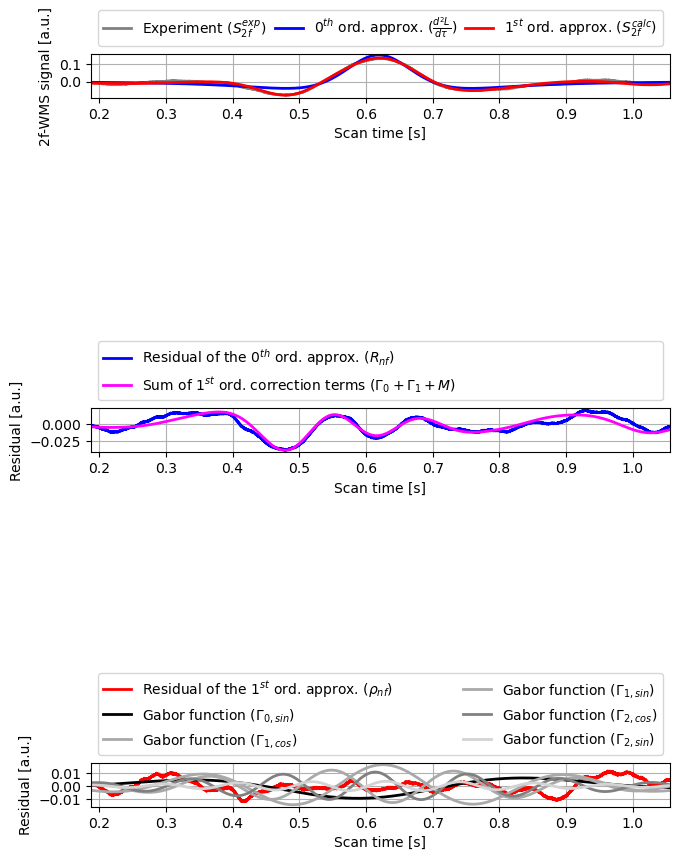

[[Fit Statistics]]
    # fitting method   = differential_evolution
    # function evals   = 2037
    # data points      = 4280
    # variables        = 3
    chi-square         = 1.03413958
    reduced chi-square = 2.4179e-04
    Akaike info crit   = -35638.4329
    Bayesian info crit = -35619.3478
    R-squared          = 0.94595855
[[Variables]]
    a0: -9.3281e-04 +/- 7.5658e-06 (0.81%) (init = 0.1823376)
    a1:  1.48479969 +/- 1.9381e-04 (0.01%) (init = 1.055)
    a2:  0.14175186 +/- 4.1008e-04 (0.29%) (init = 0.17116)
[[Correlations]] (unreported correlations are < 0.100)
    C(a0, a2) = -0.8929
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 287
    # data points      = 4280
    # variables        = 14
    chi-square         = 0.17202390
    reduced chi-square = 4.0324e-05
    Akaike info crit   = -43293.4330
    Bayesian info crit = -43204.3691
##  Warning: uncertainties could not be estimated:
[[Variables]]
    a0:   -0.0009328135 (fixed)
    a1:  

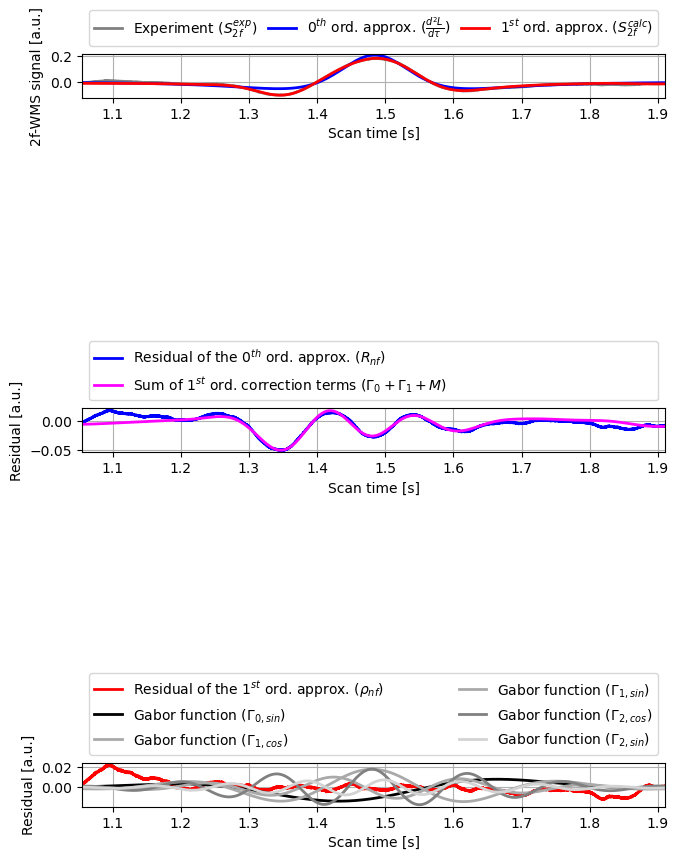

In [8]:
# Pracovní adresář
aver_dir = os.path.join(os.getcwd(), 'aver_dir')  # Definice pracovního adresáře
os.makedirs(aver_dir, exist_ok=True)  # Zajistí, že adresář existuje

# Souhrnný PDF soubor pro fitování všech peaků
Out2 = PdfPages(os.path.join(aver_dir, 'out2f_fit.pdf'))

# Iterace přes jednotlivé píky
for i in range(1, numpeak + 1):
    j = i - 1  # Indexování pro ukládání výsledků

    # Vstupní soubor pro aktuální peak
    InputFilePeaks = os.path.join(aver_dir, f'Peak_{i}.txt')
    Dataset = np.loadtxt(InputFilePeaks, skiprows=1, delimiter=',')
    x = Dataset[:, 0]
    y = Dataset[:, 1]
    
    # Výstupní PDF pro aktuální peak
    Out3i = PdfPages(os.path.join(aver_dir, f'out_peakfit_{i}.pdf'))

    params = lm.Parameters()
    params.add('a0', value=np.maximum(np.abs(np.amax(-y)),np.abs(np.amin(-y))), min=10*np.amin(-y), max=10*np.amax(-y))
    params.add('a1', value=np.amin(x)-(np.amax(x)-np.amin(x))/2, min=np.amin(x), max=np.amax(x))
    params.add('a2', value=(np.amax(x)-np.amin(x))/5, min=(np.amax(x)-np.amin(x))/10, max=(np.amax(x)-np.amin(x))/2)

    #model = lm.Model(D2gaussianA)
    model = lm.Model(D2lorentzianA)
     #result[j] = model.fit(y, params, x=x, method='leastsq')
    result[j] = model.fit(y, params, xs=x, method='differential_evolution')
    
    lm.report_fit(result[j])

    par[j] = result[j].best_values
   
    resdata[j] = result[j].residual
    
    ofst[j] = np.mean(resdata[j])
    #ofst[j] = 0
    
    def residual(params, x, resdata):
        "Gabor polynomial"
        params['a0']= Parameter(name = 'a0', value = par[j]['a0'] , vary = False)
        params['a1']= Parameter(name = 'a1', value = par[j]['a1'] , vary = False)
        params['a2']= Parameter(name = 'a2', value = par[j]['a2'] , vary = False)

        off = params['off']
        params['off']= Parameter(name = 'off', value = ofst[j] , vary = False)
        k2 = params['k2']
        k4 = params['k4']
        k6 = params['k6']

        k8 = params['k8']
        fi8 = params['fi8']
        
        k10 = params['k10']
        fi10 = params['fi10']

        fi6 = params['fi6']
        fi4 = params['fi4']
        fi2 = params['fi2']
        
        a0 = params['a0']
        a1 = params['a1']
        a2 = params['a2']

        w = params['w']

        sigma = a2/np.sqrt(2*np.log(2))
        gabor10 = np.cos(2*np.pi*(5/2)*(x-a1)/(2*a2)+fi10)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor8 = np.cos(2*np.pi*(4/2)*(x-a1)/(2*a2)+fi8)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor6 = np.sin(2*np.pi*(3/2)*(x-a1)/(2*a2)+fi6)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor4 = np.cos(2*np.pi*(2/2)*(x-a1)/(2*a2)+fi4)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        gabor2 = np.sin(2*np.pi*(1/2)*(x-a1)/(2*a2)+fi2)*a0/((w*sigma)*np.sqrt(2*np.pi))*np.exp(-(x-a1)**2/(2*(w*sigma)**2))
        
        return off + k10*gabor10 + k8*gabor8 + k6*gabor6 + k4*gabor4 + k2*gabor2 - resdata
        #return off + k8*gabor8 + k6*gabor6 + k4*gabor4 + k2*gabor2 - resdata
        #return off + k6*gabor6 + k4*gabor4 + k2*gabor2 - resdata
    
        # create a set of Parameters
    
    #params.add('off', min=-par[j]['a0'], max=par[j]['a0'], vary = False)
    params.add('off', min=-3*ofst[j], max=3*ofst[j], vary = False)
    params.add('k6', value=1.0, min=-50, max=50.0, vary = True)
    params.add('k4', value=1.0, min=-50, max=50.0, vary = True)
    params.add('k2', value=1.0, min=-50, max=50.0, vary = True)
    params.add('k8', value=1.0, min=-50, max=50.0, vary = True)
    params.add('k10', value=1.0, min=-50, max=50.0, vary = True)
    params.add('fi10', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi8', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi6', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi4', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('fi2', value=0.0, min=-np.pi, max=np.pi, vary = True)
    params.add('w', value=1.33, min= 1/3, max=7/3, vary = True)
    #params.add('w', value=1/2, min= 1/3, max=2/3, vary = True)
       
    # do fit, here with leastsq model
    minner[j] = Minimizer(residual, params, fcn_args=(x, resdata[j]))
    res2ult[j] = minner[j].minimize(method = 'leastsq')
    # res2ult[j] = minner[j].minimize(method = 'differential_evolution')

    par2am[j] = res2ult[j].params
    #par2am[j].pretty_print()

    offj=par2am[j]['off'].value
    a0j=par2am[j]['a0'].value
    a1j=par2am[j]['a1'].value
    a2j=par2am[j]['a2'].value
    k6j=par2am[j]['k6'].value
    k4j=par2am[j]['k4'].value
    k2j=par2am[j]['k2'].value
    k8j=par2am[j]['k8'].value
    k10j=par2am[j]['k10'].value
    fi10j=par2am[j]['fi10'].value
    fi8j=par2am[j]['fi8'].value
    fi6j=par2am[j]['fi6'].value
    fi4j=par2am[j]['fi4'].value
    fi2j=par2am[j]['fi2'].value
    sigmaj = a2j/np.sqrt(2*np.log(2))
    wj=par2am[j]['w'].value

    gabor10[j] = np.sin(5*np.pi*(x-a1j)/(2*a2j)+fi10j)*k10j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor8[j] = np.cos(4*np.pi*(x-a1j)/(2*a2j)+fi8j)*k8j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor6[j] = np.sin(3*np.pi*(x-a1j)/(2*a2j)+fi6j)*k6j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor4[j] = np.cos(2*np.pi*(x-a1j)/(2*a2j)+fi4j)*k4j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))
    gabor2[j] = np.sin(1*np.pi*(x-a1j)/(2*a2j)+fi2j)*k2j*a0j/(wj*sigmaj*np.sqrt(2*np.pi))*np.exp(-(x-a1j)**2/(2*(wj*sigmaj)**2))

    res2data[j] = res2ult[j].residual
    
    # calculate final result
    fin2ual[j] = resdata[j] + res2data[j]
    
    # write error report
    report_fit(res2ult[j])    
    
    # Uložení do CSV

    output_csv = os.path.join(aver_dir, f'goutput_{i}.csv')
    
    # write signal curve after Gabor fitting into csv file{x, result[j].best_fit-fin2ual[j]}
    # Create a DataFrame directly for each index j
    df = pd.DataFrame({'x': x, 'result_minus_fin2ual_plus_offset': result[j].best_fit - fin2ual[j] + offj})
    # Write DataFrame to CSV file, naming it based on index j
    #goutput_filename = f'goutput_{j+1}.csv'
    goutput_filename = os.path.join(aver_dir, f'goutput_{i}.csv')
    df.to_csv(goutput_filename, index=False)
    print(f'Data written to {goutput_filename} successfully.')
    
    fig2 = plt.figure(2)
    
    ax1=plt.subplot(311)
    line2, = plt.plot(x, y, 'grey', linewidth=2, label= r'Experiment ($S_{2f}^{exp}$)')
    line3, = plt.plot(x, result[j].best_fit, 'blue', linewidth=2, label= r'$0^{th}$ ord. approx. ($\frac{d^{2}L}{d\tau}$)')
    line1, = plt.plot(x, result[j].best_fit-fin2ual[j], 'red', linewidth=2, label= r'$1^{st}$ ord. approx. ($S_{2f}^{calc}$)')
    plt.legend(handler_map={line1: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,1.02,1,0.2), loc="lower left", mode="expand", ncol=3)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"2f-WMS signal [a.u.]")
    plt.axis([1.0*np.amin(x), 1.0*np.amax(x), 1.2*np.amin(y), 1.2*np.amax(y),])
    plt.grid(True)

    ax2=plt.subplot(312, sharex=ax1)
    line4, = plt.plot(x, -result[j].residual, 'blue',linewidth=2, label=r'Residual of the $0^{th}$ ord. approx. ($R_{nf}$)')
    line5, = plt.plot(x, -fin2ual[j], 'magenta', linewidth=2, label=r'Sum of $1^{st}$ ord. correction terms ($\Gamma_0 + \Gamma_1 + M$)')
    plt.legend(handler_map={line4: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,1.02,1,0.2), loc="lower left", mode="expand", ncol=1)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"Residual [a.u.]")
    #plt.axis([1.0*np.amin(x), 1.0*np.amax(x), -1.5*np.amax(result[j].residual), -2.5*np.amin(result[j].residual),])
    plt.grid(True)
    
    ax3=plt.subplot(313, sharex=ax1)
    line6, = plt.plot(x, res2ult[j].residual, 'red',linewidth=2, label=r'Residual of the $1^{st}$ ord. approx. ($\rho_{nf}$)')
    line7, = plt.plot(x, -gabor2[j], 'black',linewidth=2, label= r'Gabor function ($\Gamma_{0,sin}$)')
    line8, = plt.plot(x, -gabor4[j], 'darkgray',linewidth=2, label= r'Gabor function ($\Gamma_{1,cos}$)')
    line9, = plt.plot(x, -gabor6[j], 'darkgrey',linewidth=2, label=r'Gabor function ($\Gamma_{1,sin}$)')
    line10, = plt.plot(x, gabor8[j], 'grey',linewidth=2, label=r'Gabor function ($\Gamma_{2,cos}$)')
    line11, = plt.plot(x, gabor10[j], 'lightgrey',linewidth=2, label=r'Gabor function ($\Gamma_{2,sin}$)')
    #line11, = plt.plot(x, -gabor2[j]-gabor4[j]-gabor6[j]-gabor8[j], 'm:',linewidth=4)
    plt.legend(handler_map={line6: HandlerLine2D(numpoints=1)})
    plt.legend(bbox_to_anchor=(0,1.02,1,0.2), loc="lower left", mode="expand", ncol=2)
    plt.xlabel(r"Scan time [s]")
    plt.ylabel(r"Residual [a.u.]")
    #plt.axis([1.0*np.amin(x), 1.0*np.amax(x), 2.0*offj-1.5*np.amax(result[j].residual), 2.0*offj-2.5*np.amin(result[j].residual),])
    plt.grid(True)
    
    plt.tight_layout()
    a4 = plt.gcf()
    a4.set_size_inches([7,10])
    a4.savefig(Out2, format='pdf')
    a4.savefig(Out3i, format='pdf')
    plt.show()

    Out3i.close()
    
Out2.close()

Nový výstup uložen do souboru: C:\Users\vaclav\ga2bor\aver_dir\goutput.csv


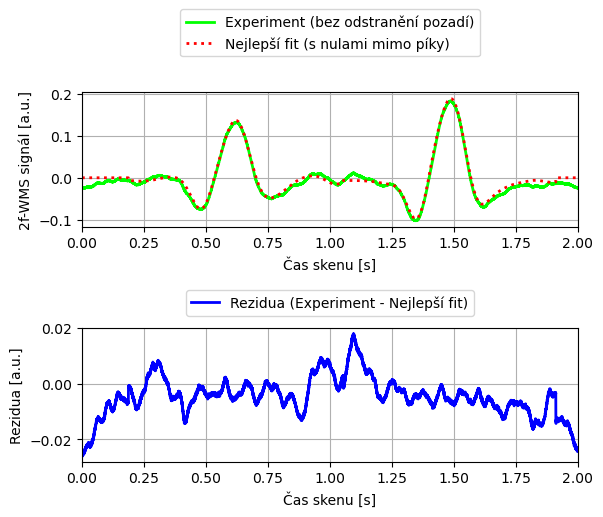

In [9]:
###Reanalýza výsledků

# Definice pracovního adresáře
aver_dir = os.path.join(os.getcwd(), 'aver_dir')  # Pracovní adresář
os.makedirs(aver_dir, exist_ok=True)  # Zajištění, že adresář existuje

# Načtení dat pro první peak z pracovního adresáře
OutputFile1 = os.path.join(aver_dir, 'goutput_1.csv')
Dataset1 = np.loadtxt(OutputFile1, skiprows=1, delimiter=',')  # Načtení datového souboru
g1_x = Dataset1[:, 0]  # Časové hodnoty pro první peak
g1_y = Dataset1[:, 1]  # Amplitudové hodnoty pro první peak

# Načtení dat pro druhý peak z pracovního adresáře
OutputFile2 = os.path.join(aver_dir, 'goutput_2.csv')
Dataset2 = np.loadtxt(OutputFile2, skiprows=1, delimiter=',')  # Načtení datového souboru
g2_x = Dataset2[:, 0]  # Časové hodnoty pro druhý peak
g2_y = Dataset2[:, 1]  # Amplitudové hodnoty pro druhý peak

# Vytvoření nového pole y s hodnotami nula mimo rozsah peaků
goutput_y = np.zeros_like(xs)

# Nastavení hodnot y pro první peak
goutput_y[(xs >= np.min(g1_x)) & (xs <= np.max(g1_x))] = g1_y[(g1_x >= np.min(g1_x)) & (g1_x <= np.max(g1_x))]

# Nastavení hodnot y pro druhý peak
goutput_y[(xs >= np.min(g2_x)) & (xs <= np.max(g2_x))] = g2_y[(g2_x >= np.min(g2_x)) & (g2_x <= np.max(g2_x))]

# Uložení nového pole do CSV souboru v pracovním adresáři
goutput_file = os.path.join(aver_dir, 'goutput.csv')
goutput = np.column_stack((xs, goutput_y))
np.savetxt(goutput_file, goutput, delimiter=',', header='x,y', comments='')
print(f'Nový výstup uložen do souboru: {goutput_file}')

# Vykreslení grafů pomocí Matplotlib
fig3 = plt.figure(2)

# První subplot: Experimentální data a nejlepší fit
ax1 = plt.subplot(211)
plt.plot(xs, ys, 'lime', linewidth=2, label='Experiment (bez odstranění pozadí)')
plt.plot(xs, goutput_y, 'red', linestyle="dotted", linewidth=2, label='Nejlepší fit (s nulami mimo píky)')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.67), ncol=1)
plt.xlabel("Čas skenu [s]")
plt.ylabel("2f-WMS signál [a.u.]")
plt.xlim([0, 2])
plt.grid(True)

# Druhý subplot: Rezidua
ax2 = plt.subplot(212)
plt.plot(xs, ys - goutput_y, 'blue', linewidth=2, label='Rezidua (Experiment - Nejlepší fit)')
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 1.33), ncol=1)
plt.xlabel("Čas skenu [s]")
plt.ylabel("Rezidua [a.u.]")
plt.xlim([0, 2])
plt.grid(True)

# Nastavení prostoru mezi subgrafy
fig3.subplots_adjust(hspace=0.75)

# Zobrazení grafu
plt.show()

Graf pro Peak 1 byl uložen do: C:\Users\vaclav\ga2bor\aver_dir\peak_1_plot.png


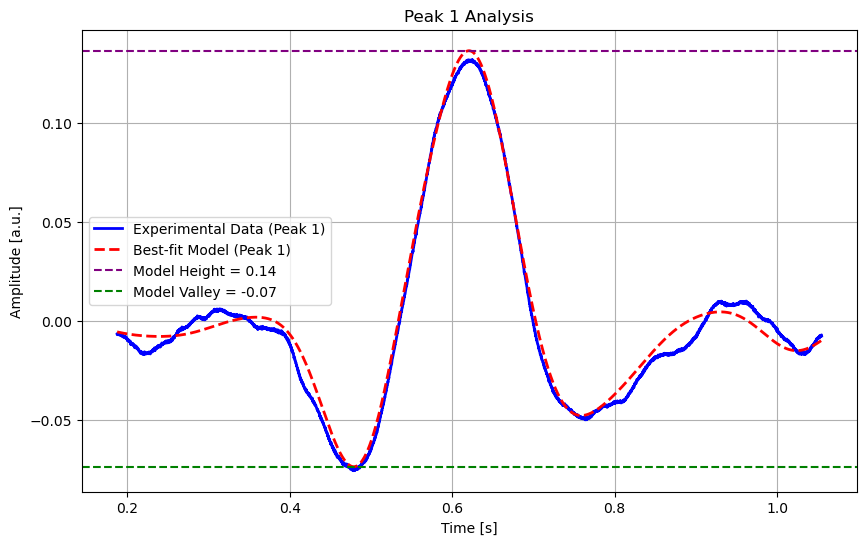

Peak 1:
  Výška píku (Height): 0.1362566676549799
  Amplituda (Amplitude): 0.21004664993981348
Graf pro Peak 2 byl uložen do: C:\Users\vaclav\ga2bor\aver_dir\peak_2_plot.png


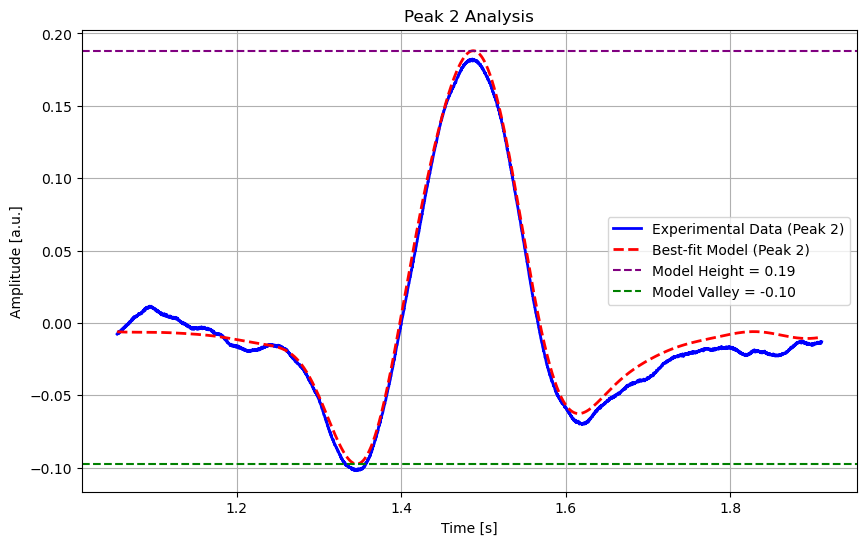

Peak 2:
  Výška píku (Height): 0.18805267809560192
  Amplituda (Amplitude): 0.28557664852289344
Souhrn peaků byl uložen do souboru: C:\Users\vaclav\ga2bor\aver_dir\peaks_summary.txt


In [10]:
###Doplnujici analza pro jednotlive piky

# Nastavení pracovního adresáře
aver_dir = os.path.join(os.getcwd(), 'aver_dir')  # Pracovní adresář
os.makedirs(aver_dir, exist_ok=True)  # Zajištění existence adresáře

# Počet peaků (upravit podle počtu dostupných souborů)
numpeak = 2  # Například pokud máte dva píky

# Inicializace seznamu pro uložení shrnutí peaků
peaks_summary = []  # Tento seznam bude obsahovat informace o všech píkech

# Iterace přes všechny soubory pro píky
for i in range(1, numpeak + 1):
    # Cesta k experimentálnímu datovému souboru (Peak_#.txt)
    PeakFile = os.path.join(aver_dir, f'Peak_{i}.txt')
    Dataset_exp = np.loadtxt(PeakFile, skiprows=1, delimiter=',')  # Načtení experimentálních dat

    # Časové a amplitudové hodnoty pro experimentální data
    exp_x = Dataset_exp[:, 0]  # Časové hodnoty
    exp_y = Dataset_exp[:, 1]  # Amplitudové hodnoty

    # Cesta k modelovaným datům (goutput_#.csv)
    ModelFile = os.path.join(aver_dir, f'goutput_{i}.csv')
    Dataset_model = np.loadtxt(ModelFile, skiprows=1, delimiter=',')  # Načtení modelových dat

    # Časové a amplitudové hodnoty pro model
    model_x = Dataset_model[:, 0]  # Časové hodnoty
    model_y = Dataset_model[:, 1]  # Amplitudové hodnoty

    # Výpočet výšky píku (maximum modelových dat)
    peak_height = np.max(model_y)

    # Výpočet amplitudy píku (rozdíl mezi maximem a minimem modelových dat)
    peak_amplitude = np.max(model_y) - np.min(model_y)

    # Uložení výsledků do seznamu
    peaks_summary.append({
        "Peak Number": i,
        "Height (Peak)": peak_height,
        "Amplitude (Peak - Valley)": peak_amplitude
    })

    # Vykreslení grafu pro tento peak
    plt.figure(figsize=(10, 6))
    plt.plot(exp_x, exp_y, 'blue', label=f'Experimental Data (Peak {i})', linewidth=2)
    plt.plot(model_x, model_y, 'red', linestyle='--', label=f'Best-fit Model (Peak {i})', linewidth=2)
    plt.axhline(y=peak_height, color='purple', linestyle='--', label=f'Model Height = {peak_height:.2f}')
    plt.axhline(y=np.min(model_y), color='green', linestyle='--', label=f'Model Valley = {np.min(model_y):.2f}')
    plt.title(f'Peak {i} Analysis')
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude [a.u.]')
    plt.legend()
    plt.grid(True)

    # Uložit graf do souboru
    peak_plot_file = os.path.join(aver_dir, f'peak_{i}_plot.png')
    plt.savefig(peak_plot_file, dpi=300)
    print(f'Graf pro Peak {i} byl uložen do: {peak_plot_file}')

    # Zobrazení grafu interaktivně
    plt.show()

    # Výstup výsledků pro aktuální peak
    print(f"Peak {i}:")
    print(f"  Výška píku (Height): {peak_height}")
    print(f"  Amplituda (Amplitude): {peak_amplitude}")

# Uložení výsledků do textového souboru
summary_file = os.path.join(aver_dir, 'peaks_summary.txt')
with open(summary_file, 'w') as f:
    f.write("Summary of Peaks\n")
    f.write("=================\n")
    for summary in peaks_summary:
        f.write(f"Peak {summary['Peak Number']}:\n")
        f.write(f"  Height: {summary['Height (Peak)']}\n")
        f.write(f"  Amplitude: {summary['Amplitude (Peak - Valley)']}\n")
        f.write("\n")

print(f"Souhrn peaků byl uložen do souboru: {summary_file}")

Peak 1:
  - Výška od nuly (h2f): 0.1318039786666667
  - Amplituda (a2f): 0.1947916731933333
Peak 2:
  - Výška od nuly (h2f): 0.1823375666666664
  - Amplituda (a2f): 0.2684599334333331


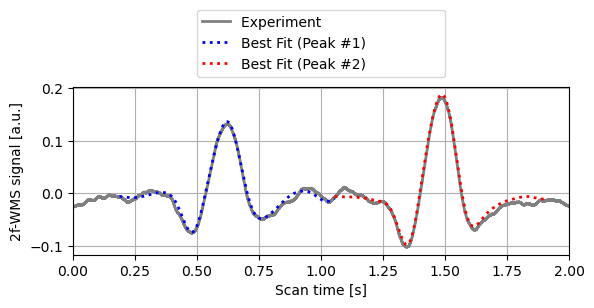

In [11]:
fig4 = plt.figure(2)

ax1 = plt.subplot(211)
plt.plot(xs, ys, 'grey', linewidth=2,  label='Experiment                           ')
plt.plot(g1_x, g1_y, 'blue', linestyle="dotted", linewidth=2, label='Best Fit (Peak #1)')
plt.plot(g2_x, g2_y, 'red', linestyle="dotted", linewidth=2, label='Best Fit (Peak #2)')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.5), ncol=1)
plt.xlabel("Scan time [s]")
plt.ylabel("2f-WMS signal [a.u.]")
plt.xlim([0, 2])
plt.grid(True)

h2f_values = []  # Výšky od nuly
a2f_values = []  # Amplitudy

# Pro každý peak v poli peak_objects
for peak in peak_objects:
    h2f = peak.s2_max  # Výška od nuly
    a2f = peak.s2_ampl  # Amplituda

    h2f_values.append(h2f)
    a2f_values.append(a2f)

# Výpis výsledků
for i, (h2f, a2f) in enumerate(zip(h2f_values, a2f_values)):
    print(f"Peak {i+1}:")
    print(f"  - Výška od nuly (h2f): {h2f}")
    print(f"  - Amplituda (a2f): {a2f}")